In [1]:
# input
rep_info_file = "../../data/tedId-numPro-numPredPro-numAnnoPro-isAnno.tsv"
# output
fig_file = "./fig/pred_consistency_ted.pdf"

In [2]:
import pandas as pd

df_rep = pd.read_table(rep_info_file, header=None, names=["ted_id", "num_pro", "num_pred_pro", "num_anno_pro", "is_anno"])

In [3]:
import tqdm

bins = []
base = 2
max_power = 10
for i in range(0, max_power):
    bins.append([base ** i, base ** (i + 1) - 1])
bins.append([base ** max_power, df_rep['num_pro'].max().item()])
def get_bin_idx(n_member):
    cur_bin_idx = None
    for idx, bin in enumerate(bins):
        lower, upper = bin
        if n_member >= lower and n_member <= upper:
            cur_bin_idx = idx
    assert cur_bin_idx != None
    return cur_bin_idx

df_rep['bin_idx'] = df_rep["num_pro"].map(lambda x: get_bin_idx(x))

data = []
for (idx, ), df_idx in tqdm.tqdm(df_rep.groupby(["bin_idx"])):
    data.append({
        "bin_idx": idx,
        "num_pro": df_idx['num_pro'].sum(),
        "num_pro_in_anno_ted": df_idx[df_idx['is_anno'] == 1]['num_pro'].sum(),
        "num_pred_pro": df_idx['num_pred_pro'].sum(),
        "num_pred_pro_in_anno_ted": df_idx[df_idx['is_anno'] == 1]['num_pred_pro'].sum(),
    })
df = pd.DataFrame(data)

df['pro_pred_ratio'] = df['num_pred_pro'] / df['num_pro']
df['pro_pred_ratio_in_anno_ted'] = df["num_pred_pro_in_anno_ted"] / df["num_pro_in_anno_ted"]

100%|██████████| 11/11 [00:01<00:00,  7.72it/s]


In [4]:
df

,bin_idx,num_pro,num_pro_in_anno_ted,num_pred_pro,num_pred_pro_in_anno_ted,pro_pred_ratio,pro_pred_ratio_in_anno_ted
0,0,6921092,371319,6921092,371319,1.000000,1.000000
1,1,6597990,555186,6242093,540262,0.946060,0.973119
2,2,5774519,584765,5314603,562083,0.920354,0.961212
3,3,4816312,553936,4332760,527675,0.899601,0.952592
4,4,4431536,594819,3909430,562361,0.882184,0.945432
5,5,4011689,637614,3459264,596210,0.862296,0.935064
6,6,3566346,652253,3008322,608767,0.843531,0.933330
7,7,3143689,679311,2595462,626780,0.825610,0.922670
8,8,2778585,754254,2238285,694650,0.805549,0.920976
9,9,1966188,669205,1567437,612872,0.797196,0.915821


([<matplotlib.axis.YTick at 0x75818ba8ca90>,
 [Text(0, 0.1, '0.1'),
  Text(0, 0.2, '0.2'),
  Text(0, 0.30000000000000004, '0.3'),
  Text(0, 0.4, '0.4'),
  Text(0, 0.5, '0.5'),
  Text(0, 0.6, '0.6'),
  Text(0, 0.7000000000000001, '0.7'),
  Text(0, 0.8, '0.8'),
  Text(0, 0.9, '0.9'),
  Text(0, 1.0, '1.0')])

Text(0, 0.5, 'Matched percentage')

Text(0.5, 0, 'Cluster size range')

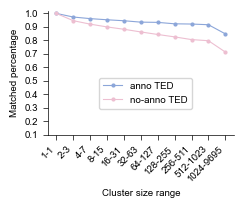

In [5]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use(f"{PROJECT_DIR}/asset/metalnet.mplstyle")

fig, ax = plt.subplots(figsize=(2.4, 1.6))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticks(df['bin_idx'], ["-".join([str(j) for j in bins[i]]) for i in df['bin_idx']], rotation=45, ha='right')

# plt.plot(df['bin_idx'], df['size_ratio'], markersize=4, marker='o')
plt.plot(df['bin_idx'], df['pro_pred_ratio_in_anno_ted'], markersize=2, marker='o')
plt.plot(df['bin_idx'], df['pro_pred_ratio'], markersize=2, marker='o')
plt.yticks(np.linspace(0.1, 1.0, 10))

plt.ylabel("Matched percentage")
plt.xlabel("Cluster size range")
plt.legend(
    labels=[# 'total protein',
            'anno TED',
            'no-anno TED'],
    loc='upper right',
    bbox_to_anchor=(0.8,.5)
)

fig.savefig(fig_file, bbox_inches="tight", transparent=True)